<a href="https://colab.research.google.com/github/miguelmorandini/am-t4-s1a2026/blob/main/MultiNeuralCredit0616.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pipeline Random Forest | Digest GaussianNB [Fase 1 - credit_base]

### Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Bibliotecas de Python

In [ ]:
!pip -q install plotly
!pip -q install yellowbrick

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

### Carregar Digest de base_credit

In [ ]:
import pickle

In [ ]:
with open('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/credit.pkt', 'rb') as f:
  X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [ ]:
X_credit_treinamento.shape, Y_credit_treinamento.shape

((1700, 3), (1700,))

In [ ]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Cria um modelo Random Forest para classificação
random_credit = RandomForestClassifier(

    # Quantidade de árvores que serão criadas na floresta
    n_estimators=10,

    # Critério utilizado para dividir os nós das árvores
    # 'entropy' utiliza o ganho de informação (Information Gain)
    criterion='entropy',

    # Define uma semente para geração de números aleatórios,
    # garantindo que os resultados sejam reproduzíveis
    random_state=0
)

# Treina o modelo Random Forest utilizando os dados de treinamento
# X_credit_treinamento -> atributos (features)
# Y_credit_treinamento -> classe alvo (target)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)

RandomForestClassifier(
    bootstrap=True,             # Amostragem aleatória com reposição
    criterion='entropy',        # Utiliza ganho de informação
    max_depth=None,             # Sem limite de profundidade
    max_features='auto',        # Seleção automática de atributos
    min_samples_leaf=1,         # Mínimo de amostras por folha
    n_estimators=10,            # Quantidade de árvores
    oob_score=False,            # Não utiliza Out-of-Bag
    random_state=0              # Garante reprodutibilidade
)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       n_estimators=10, random_state=0)

### Criando base previsora

In [ ]:
previsores_random = random_credit.predict(X_credit_teste)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy_score(Y_credit_teste, previsores_random)

0.9733333333333334

In [ ]:
confusion_matrix(Y_credit_teste, previsores_random)

array([[257,   3],
       [  5,  35]])

In [ ]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

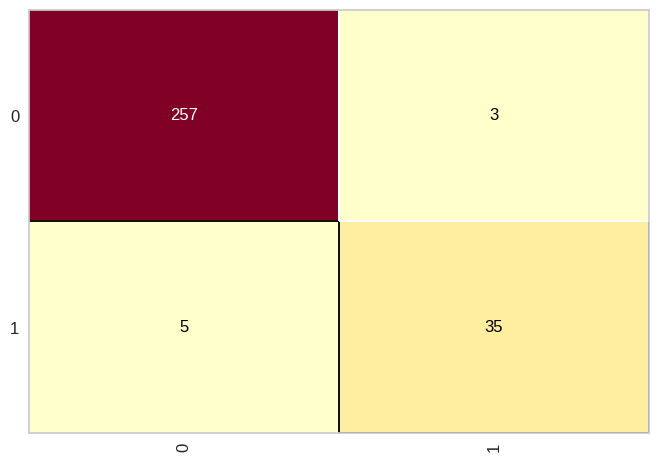

In [ ]:
cm_credit = ConfusionMatrix(random_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, previsores_random))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



## Pipeline Regressão | Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Cria o modelo de Regressão Logística para classificação
# random_state garante que os resultados sejam reproduzíveis
regressao_credit = LogisticRegression(random_state=1)

# Treina o modelo utilizando os dados de treinamento
# X_credit_treinamento -> variáveis de entrada (features)
# Y_credit_treinamento -> variável alvo (classe)
regressao_credit.fit(X_credit_treinamento, Y_credit_treinamento)

LogisticRegression(random_state=1)

In [ ]:
LogisticRegression(
    C=1.0,              # controla a regularização (menor valor = mais regularização)
    class_weight=None,  # não ajusta peso das classes
    dual=False,         # usa formulação padrão do problema
    fit_intercept=True, # inclui o bias (intercepto)
    intercept_scaling=1,# escala do intercepto
    l1_ratio=None,      # não usa Elastic Net
    max_iter=100,       # máximo de iterações para convergir
    multi_class='auto', # define automaticamente o tipo de classificação
    n_jobs=None,        # usa um único núcleo da CPU
    penalty='l2',       # regularização L2
    random_state=1,     # garante reprodutibilidade
    solver='lbfgs',     # algoritmo de otimização
    tol=0.0001,         # tolerância de parada
    verbose=0,          # sem logs durante treino
    warm_start=False    # não reaproveita treino anterior
)

LogisticRegression(multi_class='auto', random_state=1)

In [ ]:
regression_previsores = regressao_credit.predict(X_credit_teste)
regression_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, regression_previsores)

0.9533333333333334

0.9533333333333334

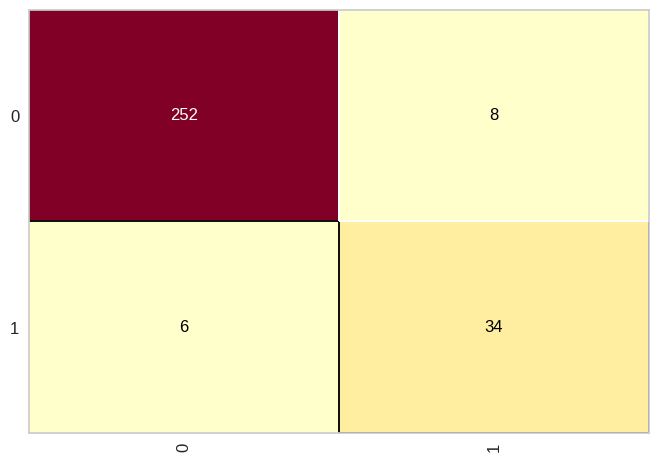

In [ ]:
from yellowbrick.classifier import ConfusionMatrix
cm_credit = ConfusionMatrix(regressao_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, regression_previsores))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       260
           1       0.81      0.85      0.83        40

    accuracy                           0.95       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.95      0.95      0.95       300



# Pipeline SVM | Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_credit = SVC(kernel='rbf', random_state=1, C=2.0)
svm_credit.fit(X_credit_treinamento, Y_credit_treinamento)

SVC(C=2.0, random_state=1)

In [ ]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, random_state=1)

In [ ]:
SVC_previsores = svm_credit.predict(X_credit_teste)
SVC_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, SVC_previsores)

0.9933333333333333

0.9933333333333333

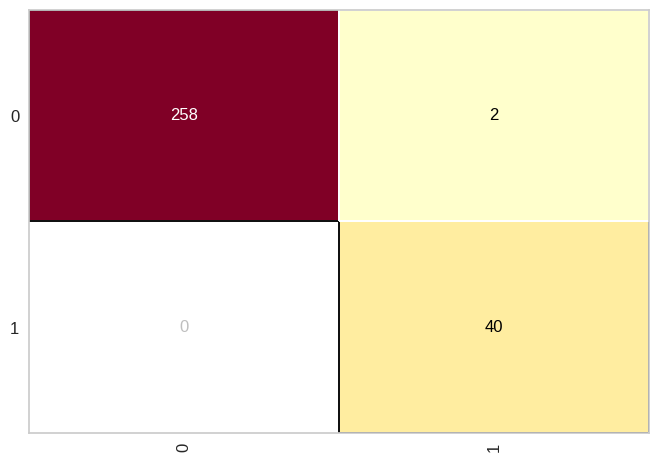

In [ ]:
svm_cm = ConfusionMatrix(svm_credit)
svm_cm.fit(X_credit_treinamento, Y_credit_treinamento)
svm_cm.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, SVC_previsores))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       260
           1       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.98      1.00      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline Redes Neurais| Digest [Fase 1 Credit Base]

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
redeneural_credit = MLPClassifier(verbose=True, max_iter=1000,
                                  tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_credit.fit(X_credit_treinamento, Y_credit_treinamento)

Iteration 1, loss = 0.66068364
Iteration 2, loss = 0.58637634
Iteration 3, loss = 0.52445014
Iteration 4, loss = 0.47287533
Iteration 5, loss = 0.42974697
Iteration 6, loss = 0.39361536
Iteration 7, loss = 0.36280311
Iteration 8, loss = 0.33617655
Iteration 9, loss = 0.31295598
Iteration 10, loss = 0.29242377
Iteration 11, loss = 0.27418493
Iteration 12, loss = 0.25792370
Iteration 13, loss = 0.24324684
Iteration 14, loss = 0.22988089
Iteration 15, loss = 0.21790954
Iteration 16, loss = 0.20705077
Iteration 17, loss = 0.19703895
Iteration 18, loss = 0.18797158
Iteration 19, loss = 0.17964888
Iteration 20, loss = 0.17204858
Iteration 21, loss = 0.16517075
Iteration 22, loss = 0.15867753
Iteration 23, loss = 0.15271321
Iteration 24, loss = 0.14729710
Iteration 25, loss = 0.14224156
Iteration 26, loss = 0.13752560
Iteration 27, loss = 0.13322034
Iteration 28, loss = 0.12930549
Iteration 29, loss = 0.12543151
Iteration 30, loss = 0.12196904
Iteration 31, loss = 0.11863603
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [ ]:
redeneural_credit.out_activation_

'logistic'

In [ ]:
previsores_redeneural = redeneural_credit.predict(X_credit_teste)
previsores_redeneural

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
accuracy_score(Y_credit_teste, previsores_redeneural)

0.9933333333333333

0.9933333333333333

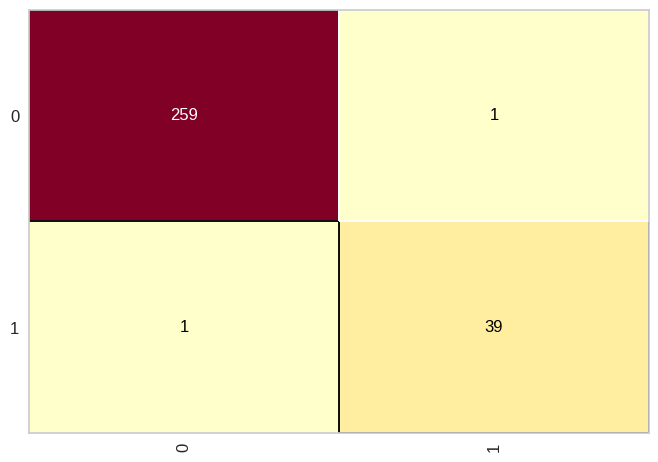

In [ ]:
rm_credit = ConfusionMatrix(redeneural_credit)
rm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
rm_credit.score(X_credit_teste, Y_credit_teste)

In [ ]:
print(classification_report(Y_credit_teste, previsores_redeneural))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       0.97      0.97      0.97        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline de Preparação de Dados | Credit_Base [Fase 1]

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p':[1,2]}

In [ ]:
grid_credit = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_credit.fit(X_credit_treinamento, Y_credit_treinamento)
melhor_parametros_credit = grid_credit.best_params_
melhor_resultado_credit = grid_credit.best_score_
print(melhor_parametros_credit)
print(melhor_resultado_credit)

{'n_neighbors': 5, 'p': 2}
0.9823529411764707


# Pipeline Orange - Regras | Credit_Base [Fase 1]

In [ ]:
!pip install Orange3

In [ ]:
import Orange

In [ ]:
base_orange_credit = Orange.data.Table('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/credit_data_regras.csv')
base_orange_credit.domain

[income, age, loan | default]

In [ ]:
credit_dividida = Orange.evaluation.testing.sample(base_orange_credit, n=0.25)
credit_dividida


([[39494.8, 28.5471, 3544.16 | 0],
  [52102.6, 19.3725, 8799.82 | 1],
  [40929.5, 20.2546, 2352.29 | 0],
  [51595.4, 28.4618, 385.403 | 0],
  [59253.1, 36.9204, 7327.28 | 0],
  ...
 ],
 [[27356.8, 63.4879, 2983.58 | 0],
  [62192.5, 46.0508, 1863.89 | 0],
  [24406.9, 37.9053, 1733.4 | 0],
  [41581.9, 22.8512, 7895.11 | 1],
  [58978, 30.331, 9442.01 | 1],
  ...
 ])

In [ ]:
treinamento_credit = credit_dividida[1]
teste_credit = credit_dividida[0]

In [ ]:
cn2_credit = Orange.classification.rules.CN2Learner()
regras_credit = cn2_credit(treinamento_credit)

In [ ]:
for regras in regras_credit.rule_list:
  print(regras)

IF age>=34.9257164876908 THEN default=0 
IF loan<=2495.13299137587 AND income>=20511.4294355735 THEN default=0 
IF loan>=7708.31562497011 AND age>=18.1760434475727 THEN default=1 
IF income>=58147.7998569608 THEN default=0 
IF loan>=6016.61509078929 AND age>=23.1489815721288 THEN default=1 
IF income<=34145.7995516248 AND loan>=4096.783714405129 THEN default=1 
IF loan>=6525.21842259918 THEN default=1 
IF income>=48790.1324336417 THEN default=0 
IF loan>=5522.786693255141 AND age>=27.0216773641296 THEN default=1 
IF income<=29724.4768752716 AND loan>=3105.4430213977303 THEN default=1 
IF age>=26.6271984525956 AND age>=33.403173910453894 THEN default=0 
IF income<=24857.6948815025 AND age>=23.238169600255798 THEN default=1 
IF age>=26.159438316244604 AND income>=34559.907035436496 THEN default=0 
IF income>=48271.4983797632 THEN default=1 
IF age>=28.4226720966399 THEN default=0 
IF age>=27.9972893036902 THEN default=1 
IF income>=40496.2558229454 AND age>=24.6631496008486 THEN default=

In [ ]:
credit_preview = Orange.evaluation.testing.TestOnTestData(treinamento_credit, teste_credit, [lambda testdata: regras_credit])

In [ ]:
credit_preview

In [ ]:
Orange.evaluation.CA(credit_preview)

array([0.978])